W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
적용된 한글 폰트: NanumBarunGothic

① 매매가격지수_아파트 파일 업로드


Saving (월) 매매가격지수_아파트.xlsx to (월) 매매가격지수_아파트 (2).xlsx

② 전세가격지수_아파트 파일 업로드


Saving (월) 전세가격지수_아파트.xlsx to (월) 전세가격지수_아파트 (2).xlsx

분석 데이터


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,월,매매가격지수,전세가격지수,월표시
0,2025-05-01,92.56,96.39,2025-05
1,2025-06-01,93.89,96.70,2025-06
2,2025-07-01,94.91,97.00,2025-07
3,2025-08-01,95.37,97.26,2025-08
4,2025-09-01,95.93,97.61,2025-09
5,2025-10-01,97.30,98.13,2025-10
6,2025-11-01,98.09,98.75,2025-11
7,2025-12-01,98.94,99.42,2025-12
8,2026-01-01,100.00,100.00,2026-01
9,2026-02-01,100.74,100.41,2026-02



아파트 매매가격지수와 전세가격지수 상관관계
피어슨 상관계수: 0.9814


,매매가격지수,전세가격지수
매매가격지수,1.000000,0.981398
전세가격지수,0.981398,1.000000


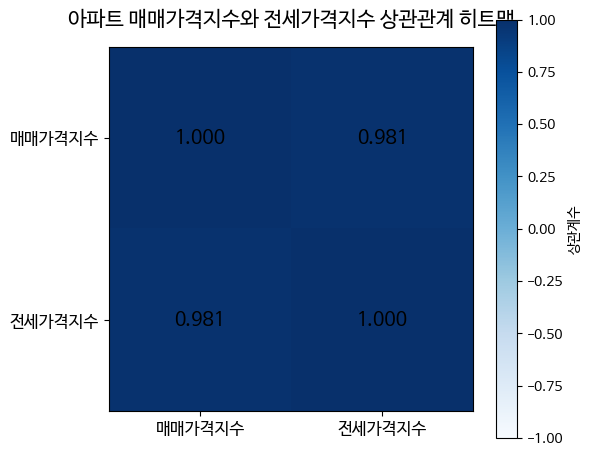

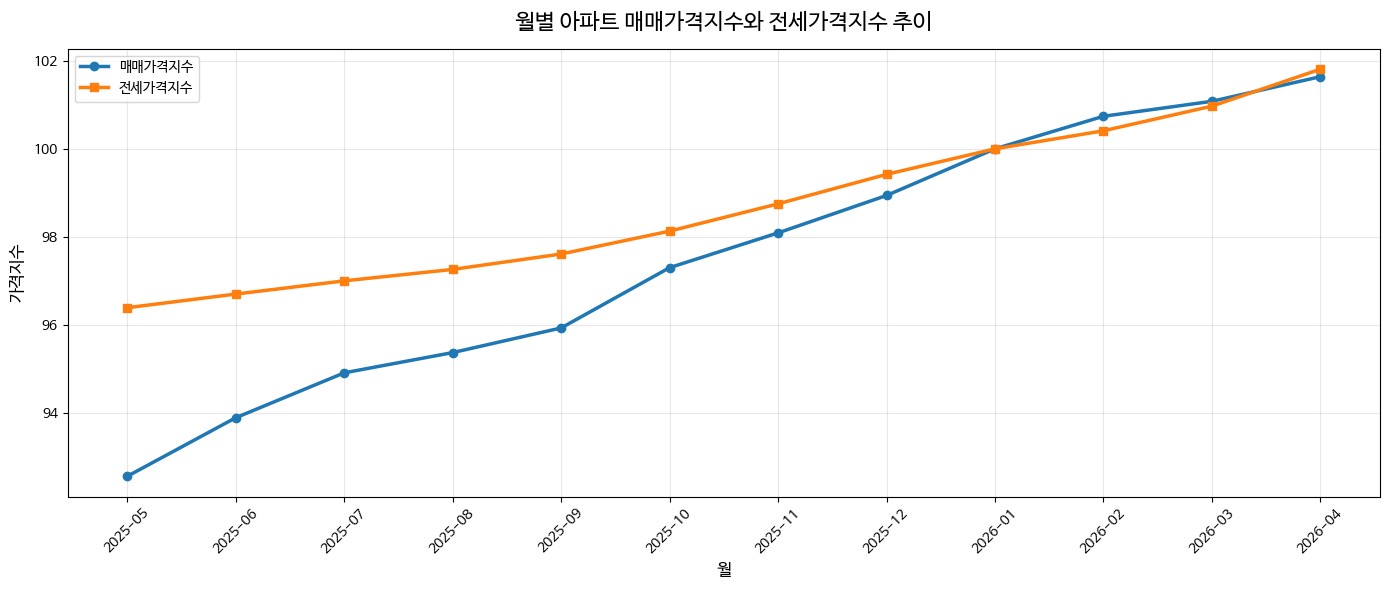

In [ ]:

# ============================================================
# 아파트 매매가격지수 vs 전세가격지수 분석
# 한글 깨짐 방지 완전 적용 / Google Colab용
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files
from IPython.display import display
import os

# ============================================================
# 1. 한글 폰트 강제 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

print("적용된 한글 폰트:", font_name)

# ============================================================
# 2. 파일 업로드
# ============================================================

print("\n① 매매가격지수_아파트 파일 업로드")
uploaded = files.upload()
sale_file = list(uploaded.keys())[0]

print("\n② 전세가격지수_아파트 파일 업로드")
uploaded = files.upload()
rent_file = list(uploaded.keys())[0]

# ============================================================
# 3. 파일 구조 기반 데이터 추출 함수
# ============================================================

def extract_index(file_name, column_name, region="서울"):
    df = pd.read_excel(file_name, header=None)

    month_row = df.iloc[0]
    type_row = df.iloc[2]

    region_idx = df[df.iloc[:, 1].astype(str).str.strip() == region].index[0]
    value_row = df.iloc[region_idx]

    data = []

    for col in range(df.shape[1]):
        month = month_row.iloc[col]
        data_type = type_row.iloc[col]

        if str(data_type).strip() == "원자료":
            value = pd.to_numeric(value_row.iloc[col], errors="coerce")

            if pd.notna(value):
                data.append([month, value])

    result = pd.DataFrame(data, columns=["월", column_name])

    result["월"] = (
        result["월"].astype(str)
        .str.replace("년", "-", regex=False)
        .str.replace("월", "", regex=False)
        .str.replace(" ", "", regex=False)
    )

    result["월"] = pd.to_datetime(result["월"], format="%Y-%m")
    result = result.sort_values("월").reset_index(drop=True)

    return result

# ============================================================
# 4. 데이터 추출 및 병합
# ============================================================

sale = extract_index(sale_file, "매매가격지수", region="서울")
rent = extract_index(rent_file, "전세가격지수", region="서울")

df = pd.merge(sale, rent, on="월", how="inner")
df["월표시"] = df["월"].dt.strftime("%Y-%m")

print("\n분석 데이터")
display(df)

# ============================================================
# 5. 상관관계 분석
# ============================================================

corr = df[["매매가격지수", "전세가격지수"]].corr()
corr_value = corr.loc["매매가격지수", "전세가격지수"]

print("\n" + "=" * 60)
print("아파트 매매가격지수와 전세가격지수 상관관계")
print("=" * 60)
print(f"피어슨 상관계수: {corr_value:.4f}")

display(corr)

# ============================================================
# 6. 상관관계 히트맵
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr.values, cmap="Blues", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, fontproperties=font_prop, fontsize=12)

ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index, fontproperties=font_prop, fontsize=12)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            fontproperties=font_prop
        )

cbar = plt.colorbar(im)
cbar.set_label("상관계수", fontproperties=font_prop)

ax.set_title(
    "아파트 매매가격지수와 전세가격지수 상관관계 히트맵",
    fontproperties=font_prop,
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. 월별 꺾은선 그래프
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df["월표시"],
    df["매매가격지수"],
    marker="o",
    linewidth=2.5,
    label="매매가격지수"
)

ax.plot(
    df["월표시"],
    df["전세가격지수"],
    marker="s",
    linewidth=2.5,
    label="전세가격지수"
)

ax.set_xlabel("월", fontproperties=font_prop, fontsize=12)
ax.set_ylabel("가격지수", fontproperties=font_prop, fontsize=12)

ax.set_title(
    "월별 아파트 매매가격지수와 전세가격지수 추이",
    fontproperties=font_prop,
    fontsize=16,
    fontweight="bold",
    pad=15
)

step = max(1, len(df) // 12)
ax.set_xticks(range(0, len(df), step))
ax.set_xticklabels(
    df["월표시"].iloc[::step],
    rotation=45,
    fontproperties=font_prop
)

ax.grid(alpha=0.3)
ax.legend(prop=font_prop, fontsize=12)

plt.tight_layout()
plt.show()